# Restricted Boltzmann Machine (RBM) from scratch con NumPy

[Carlo Aironi](mailto:c.aironi@staff.univpm.it), 2026

**Dataset**: **MNIST digit** o **Fashion MNIST** (immagini in scala di grigio, 28 $\times$ 28).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from tqdm import tqdm

## Caricamento e preprocessing dati

La RBM Bernoulli-Bernoulli richiede input **binari** $\{0,1\}$. MNIST fornisce immagini in scala di grigio 0-255 (dtype uint8): le normalizziamo in $[0,1]$ e poi le binarizziamo con una soglia.

Nota tecnica: la binarizzazione hard è una semplificazione didattica. In pratica con MNIST reale si usa spesso binarizzazione stocastica (Bernoulli sampling dei pixel grayscale normalizzati) per preservare più informazione.

Il dataset MNIST viene scaricato per intero dai server di scikit al primo utilizzo; i dati vengono poi salvati in cache locale, di default in `~/scikit_learn_data`.


In [2]:
# Hyperparameters
NV = 28 * 28      # unita' visibili (pixel)
NH = 256          # unita' latenti per RBM
EPOCHS = 60
BATCH = 256
K_TRAIN = 3       # passi di Gibbs per la fase negativa (CD-k)
K_GEN = 200      # passi di Gibbs per la generazione
LR = 0.01
DATASET = "Fashion MNIST"   # "MNIST digit" | "Fashion MNIST"
SEED = 42                    # seed base, ogni RBM usa SEED + t
np.random.seed(SEED)

In [3]:
# Data loading
def load_dataset(name: str, data_home: str | None = None):
	if name == "MNIST digit":
		print("Download MNIST digit dataset...")
		dset = fetch_openml("mnist_784", version=1, as_frame=False, data_home=data_home)
	elif name == "Fashion MNIST":
		print("Download Fashion MNIST dataset...")
		dset = fetch_openml("Fashion-MNIST", version=1, as_frame=False, data_home=data_home)
	else:
		raise ValueError(f"Dataset sconosciuto: {name}")

	X = dset.data.astype(np.float32) / 255.0
	y = dset.target
	# binarization: threshold 0.3
	X_bin = (X > 0.3).astype(np.float32)
	n_samples, n_visible = X_bin.shape
	side = int(np.sqrt(n_visible))
	print(f"n_samples = {n_samples}, n_visible = {n_visible}  (immagini {side}x{side})")
	return X, X_bin, y

X, X_bin, y = load_dataset(DATASET, data_home="DATA/")

Download Fashion MNIST dataset...
n_samples = 70000, n_visible = 784  (immagini 28x28)


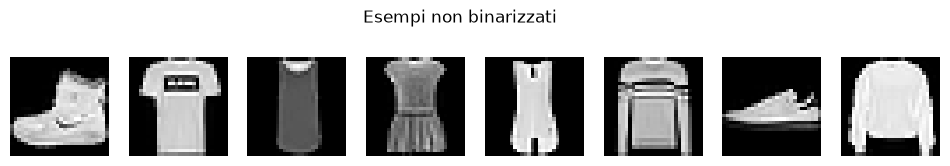

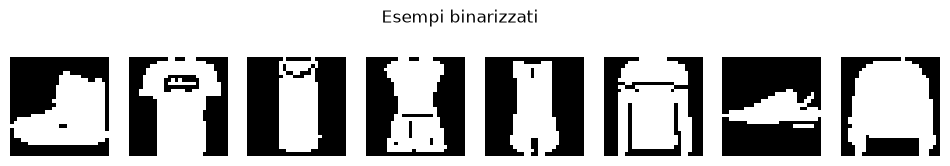

In [4]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle("Esempi non binarizzati")
plt.show()

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_bin[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle("Esempi binarizzati")
plt.show()


In [5]:
class RBM:
    def __init__(self, n_visible, n_hidden, seed=0):
        self.rng = np.random.RandomState(seed)
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.W = self.rng.normal(0, 0.01, size=(n_visible, n_hidden))
        self.b = np.zeros(n_visible)
        self.c = np.zeros(n_hidden)

    @staticmethod
    def sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    def prob_h_given_v(self, v):
        return self.sigmoid(v @ self.W + self.c)

    def sample_h_given_v(self, v):
        p_h = self.prob_h_given_v(v)
        h = (self.rng.rand(*p_h.shape) < p_h).astype(np.float64)
        return p_h, h

    def prob_v_given_h(self, h):
        return self.sigmoid(h @ self.W.T + self.b)

    def sample_v_given_h(self, h):
        p_v = self.prob_v_given_h(h)
        v = (self.rng.rand(*p_v.shape) < p_v).astype(np.float64)
        return p_v, v

    def contrastive_divergence(self, v_data, lr=0.05, k=1):
        p_h0, h0 = self.sample_h_given_v(v_data)

        v_k = v_data
        h_k = h0
        for _ in range(k):
            p_vk, v_k = self.sample_v_given_h(h_k)
            p_hk, h_k = self.sample_h_given_v(v_k)

        batch_size = v_data.shape[0]

        # implementazione "mean-field"
        grad_W = (v_data.T @ p_h0 - v_k.T @ p_hk) / batch_size
        grad_b = np.mean(v_data - v_k, axis=0)
        grad_c = np.mean(p_h0 - p_hk, axis=0)

        # # implementazione originale
        # grad_W = (v_data.T @ h0 - v_k.T @ h_k) / batch_size
        # grad_b = np.mean(v_data - v_k, axis=0)
        # grad_c = np.mean(h0 - h_k, axis=0)

        self.W += lr * grad_W
        self.b += lr * grad_b
        self.c += lr * grad_c

        recon_error = np.mean((v_data - p_vk) ** 2)
        return recon_error

    def free_energy(self, v, return_mean=True):
        """
        Free energy di un batch di esempi.
        """
        wx_b = v @ self.W + self.c
        fe = -v @ self.b - np.sum(np.log1p(np.exp(wx_b)), axis=1)

        if return_mean:
            return np.mean(fe)
        else:
            return fe

## Training loop

Definiamo una RBM con 784 unità visibili e 256 unità hidden.

Iteriamo su minibatch per più epoche, monitorando l'errore di ricostruzione medio. Ricordiamo: l'errore di ricostruzione **non è** la vera log-verosimiglianza (che resta intrattabile per via di $Z$), ma è un proxy comodo per verificare che il training stia convergendo a qualcosa di sensato.

100%|██████████| 60/60 [04:59<00:00,  5.00s/it]


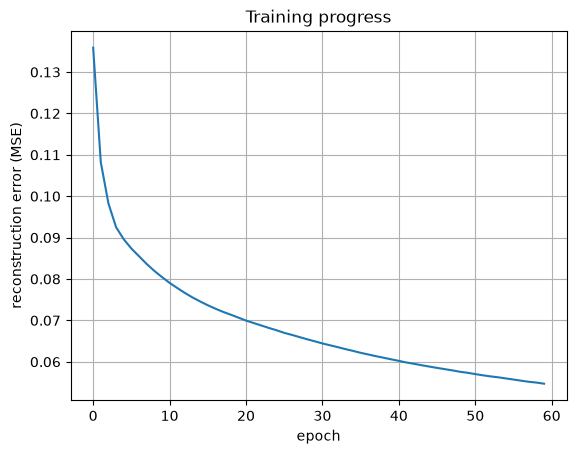

In [6]:
def train(rbm, X, n_epochs, batch_size, lr, k):
    n = X.shape[0]
    history = []
    for epoch in tqdm(range(n_epochs)):
        perm = np.random.permutation(n)
        X_shuffled = X[perm]
        errors = []
        for start in range(0, n, batch_size):
            batch = X_shuffled[start:start+batch_size]
            err = rbm.contrastive_divergence(batch, lr=lr, k=k)
            errors.append(err)
        mean_err = np.mean(errors)
        history.append(mean_err)
    return history

rbm = RBM(n_visible=NV, n_hidden=NH, seed=SEED)
history = train(rbm, X_bin, n_epochs=EPOCHS, batch_size=BATCH, lr=LR, k=K_TRAIN)

plt.plot(history)
plt.xlabel("epoch")
plt.ylabel("reconstruction error (MSE)")
plt.title("Training progress")
plt.grid()
plt.show()


## 6. Visualizzazione dei filtri appresi

Ogni colonna $j$ di $W$ (cioè $W_{:,j} \in \mathbb{R}^{n_v}$) rappresenta il **receptive field** dell'unità latente $h_j$ sullo spazio dei pixel. Su MNIST, dopo training, ci aspettiamo filtri che catturano tratti locali (curve, bordi, parti di stroke), l'analogo, in versione stocastica/non supervisionata, dei filtri convoluzionali.

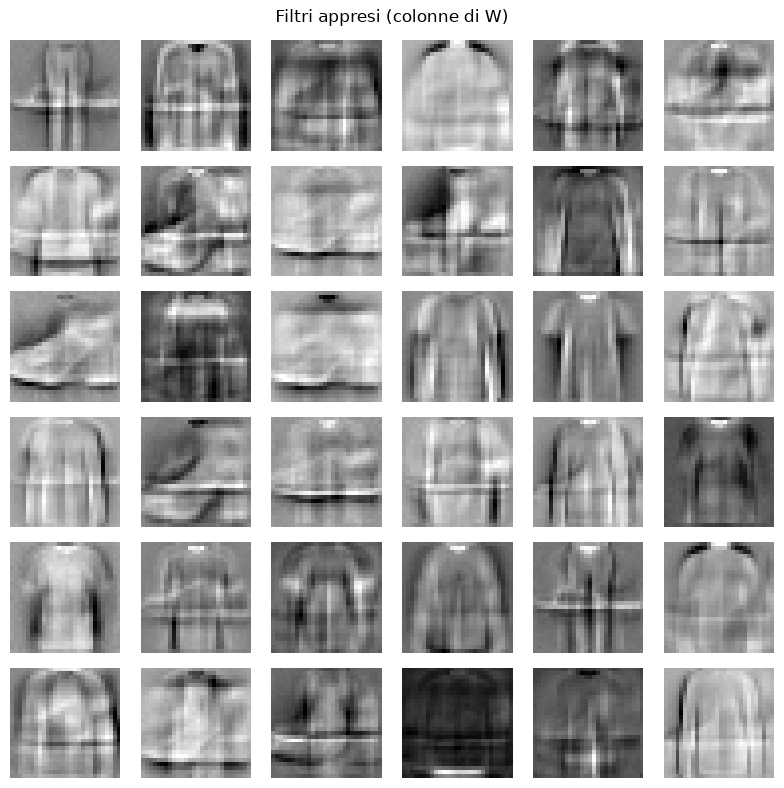

In [7]:
side = int(np.sqrt(NV))
n_filters_to_show = 36
fig, axes = plt.subplots(6, 6, figsize=(8, 8))
for j, ax in enumerate(axes.flat):
    if j < n_filters_to_show:
        ax.imshow(rbm.W[:, j].reshape(side, side), cmap='gray')
    ax.axis('off')
plt.suptitle("Filtri appresi (colonne di W)")
plt.tight_layout()
plt.show()

## Generazione: Gibbs chain dal modello allenato

Una volta allenata la RBM, possiamo generare nuovi campioni "verosimili" lanciando una catena di Gibbs **lunga** (molti step), partendo da rumore random o da un'immagine reale, e osservando dove converge la distribuzione stazionaria del modello. Più step $\sim$ più vicino alla vera $p(v)$ del modello (ma nessuna garanzia di mixing rapido; è un limite noto del Gibbs sampling su EBM multimodali).

100%|██████████| 200/200 [00:00<00:00, 8041.84it/s]


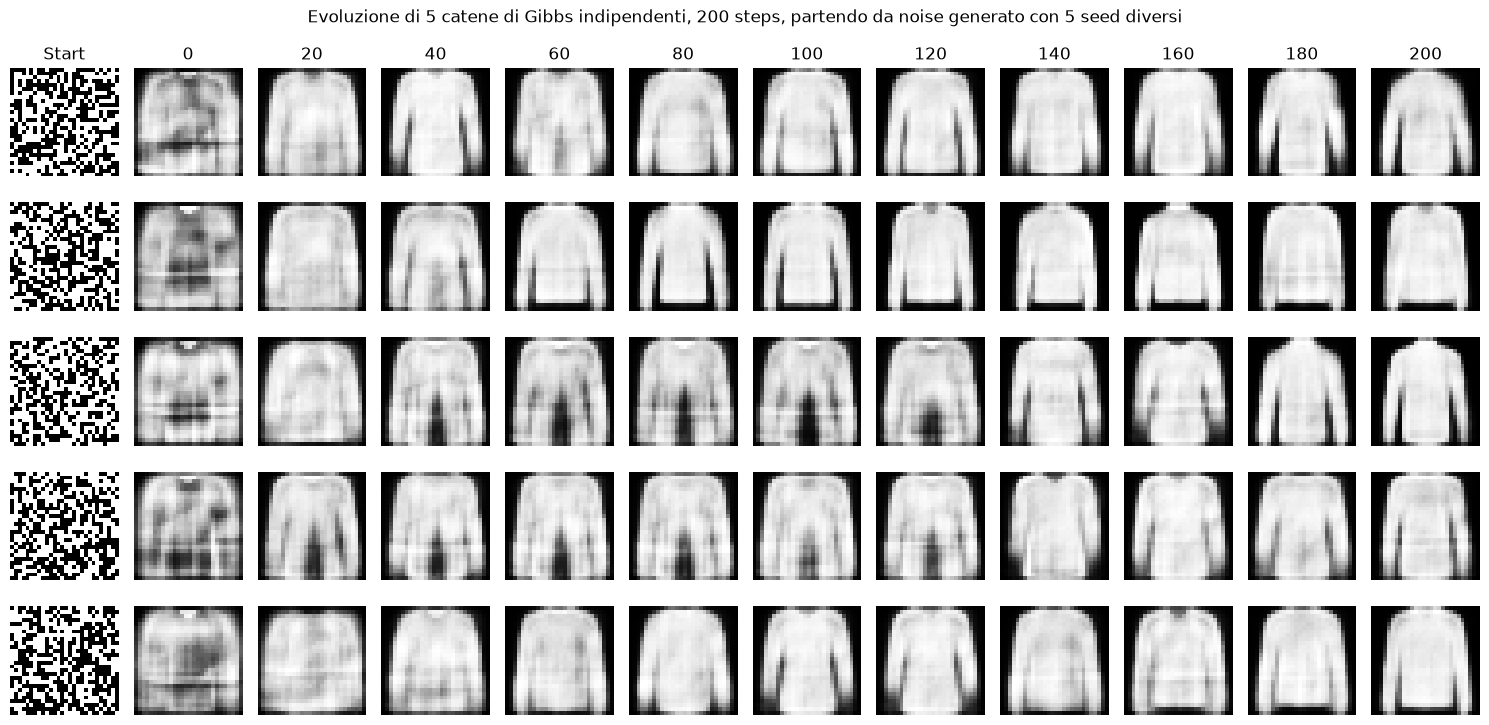

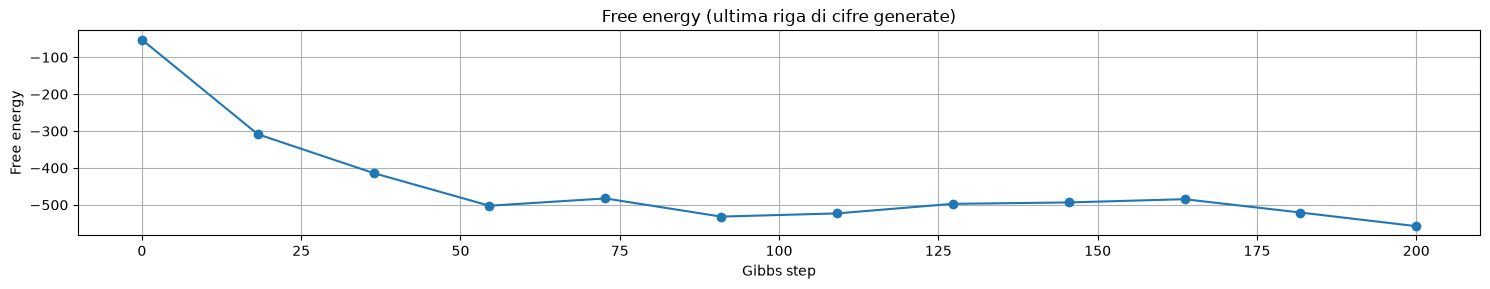

Free energy media: -447.41, std: 134.55


In [8]:
def gibbs_chain_from_noise(rbm, v_init, n_steps, rng):
    v = v_init.copy()
    snapshots = [v.copy()]
    energies = [rbm.free_energy(v)]
    for t in tqdm(range(n_steps)):
        p_h = rbm.sigmoid(v @ rbm.W + rbm.c)
        h = (rng.rand(*p_h.shape) < p_h).astype(np.float64)
        p_v = rbm.sigmoid(h @ rbm.W.T + rbm.b)
        v = (rng.rand(*p_v.shape) < p_v).astype(np.float64)
        if t % (n_steps // 10) == 0:
            snapshots.append(p_v.copy())
            energies.append(rbm.free_energy(v))
    snapshots.append(p_v.copy())
    energies.append(rbm.free_energy(v))
    return snapshots, energies

# Ogni chain parte da un rumore Bernoulli(0.5) diverso, generato con un seed distinto:
seeds = [0, 13, 244, 31, 3334]
n_steps = K_GEN
n_chains = len(seeds)

fig, axes = plt.subplots(n_chains, 12, figsize=(15, 1.5 * n_chains))
titles = ["Start"] + [f"{int(i*n_steps/10)}" for i in range(11)]
for row, s in enumerate(seeds):
    rng = np.random.RandomState(s)
    v_init = (rng.rand(1, NV) < 0.5).astype(np.float64)
    snapshots, energies = gibbs_chain_from_noise(rbm, v_init, n_steps=n_steps, rng=rng)
    for col, snap in enumerate(snapshots):
        ax = axes[row, col] if n_chains > 1 else axes[col]
        ax.imshow(snap.reshape(side, side), cmap='gray')
        if row == 0:
            ax.set_title(titles[col])
        ax.axis('off')

plt.suptitle(f"Evoluzione di {n_chains} catene di Gibbs indipendenti, {n_steps} steps, partendo da noise generato con 5 seed diversi")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,3))
plt.plot(np.linspace(0,n_steps,len(energies)), energies, marker='o')
plt.title("Free energy (ultima riga di cifre generate)")
plt.xlabel("Gibbs step")
plt.ylabel("Free energy")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Free energy media: {np.mean(energies):.2f}, std: {np.std(energies):.2f}')

Alternativa: sampling a partire da input reali (ogni chain parte da una cifra/capo di abbigliamento diverso, preso random dal dataset, ma il sampling usa un seed unico)

100%|██████████| 200/200 [00:00<00:00, 4631.42it/s]


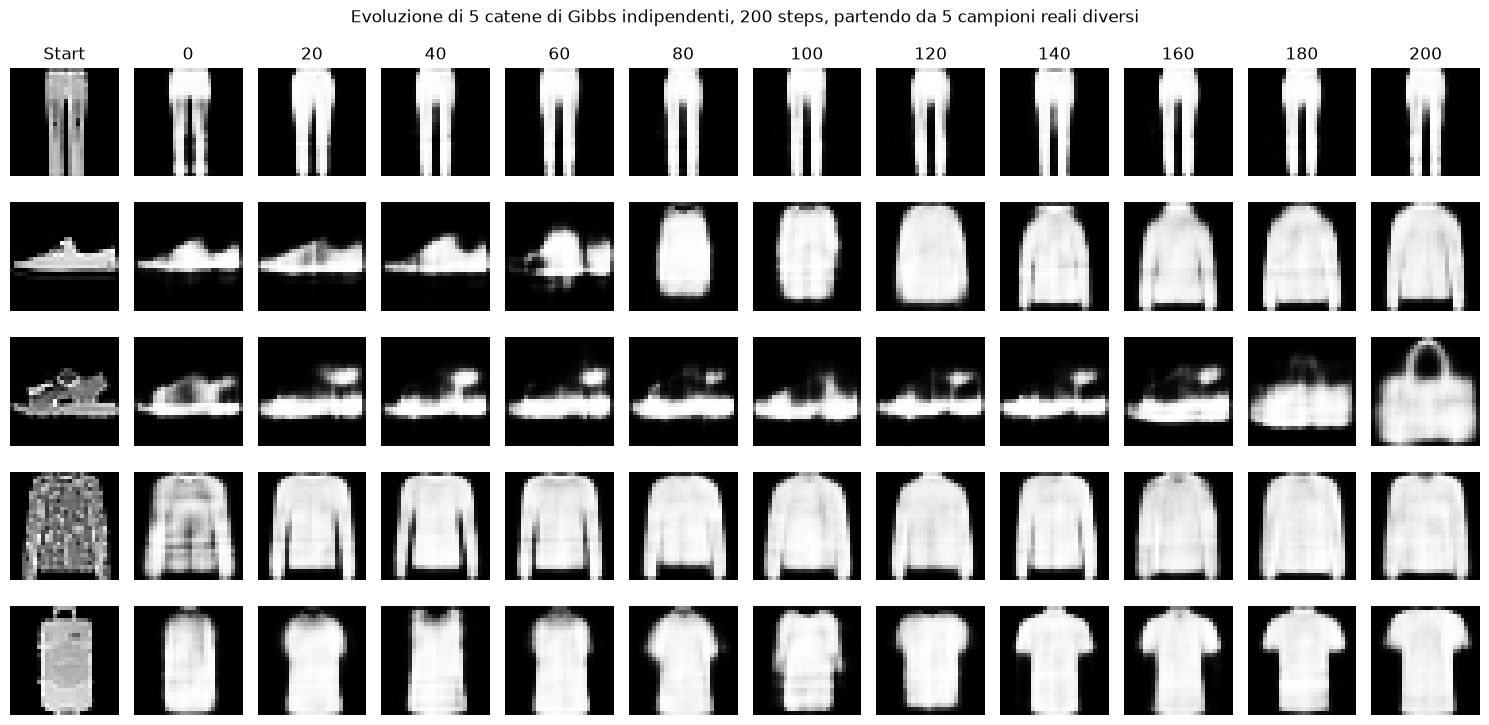

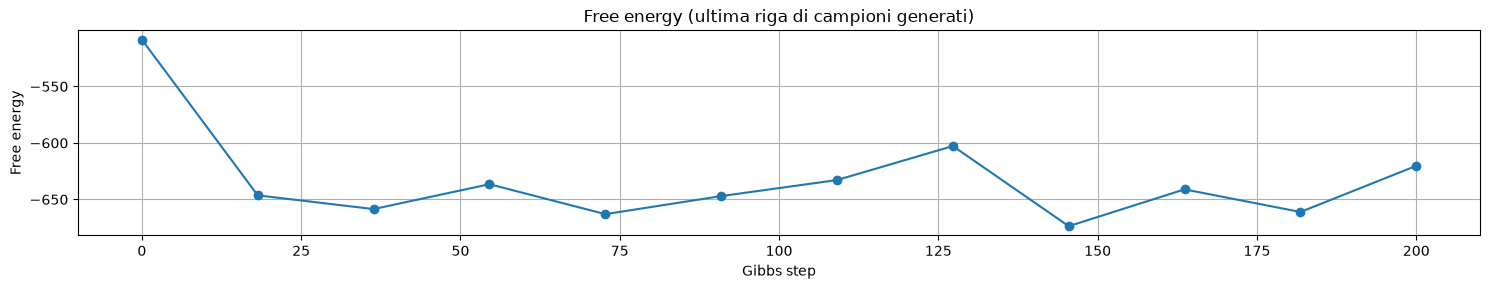

Free energy media: -632.68, std: 41.84


In [9]:
def gibbs_chain_from_data(rbm, v_init, n_steps, rng):
    v = v_init.copy()
    snapshots = [v.copy()]
    energies = [rbm.free_energy(v)]
    for t in tqdm(range(n_steps)):
        p_h = rbm.sigmoid(v @ rbm.W + rbm.c)
        h = (rng.rand(*p_h.shape) < p_h).astype(np.float64)
        p_v = rbm.sigmoid(h @ rbm.W.T + rbm.b)
        v = (rng.rand(*p_v.shape) < p_v).astype(np.float64)
        if t % (n_steps // 10) == 0:
            snapshots.append(p_v.copy())
            energies.append(rbm.free_energy(v))
    snapshots.append(p_v.copy())
    energies.append(rbm.free_energy(v))
    return snapshots, energies

rng = np.random.RandomState(47)
n_steps = K_GEN
n_chains = 5

fig, axes = plt.subplots(n_chains, 12, figsize=(15, 1.5 * n_chains))
titles = ["Start"] + [f"{int(i*n_steps/10)}" for i in range(11)]
for row in range(n_chains):
    # Seleziona una cifra casuale dal dataset
    idx = np.random.randint(len(X))
    v_init = X[idx:idx+1].astype(np.float64)
    snapshots, energies = gibbs_chain_from_data(rbm, v_init, n_steps=n_steps, rng=rng)
    for col, snap in enumerate(snapshots):
        ax = axes[row, col] if n_chains > 1 else axes[col]
        ax.imshow(snap.reshape(side, side), cmap='gray')
        if row == 0:
            ax.set_title(titles[col])
        ax.axis('off')

plt.suptitle(f"Evoluzione di {n_chains} catene di Gibbs indipendenti, {n_steps} steps, partendo da 5 campioni reali diversi")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,3))
plt.plot(np.linspace(0,n_steps,len(energies)), energies, marker='o')
plt.title("Free energy (ultima riga di campioni generati)")
plt.xlabel("Gibbs step")
plt.ylabel("Free energy")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Free energy media: {np.mean(energies):.2f}, std: {np.std(energies):.2f}')

### Inizializzazione da pseudo-campione: media globale del dataset

Le due strategie di inizializzazione usate finora (rumore Bernoulli(0.5) e campione reale singolo) rappresentano i due estremi del MET: partenza da un punto a energia altissima e priva di struttura, oppure partenza già dentro un bacino specifico. Come compromesso, si prova qui un'inizializzazione con il **pixel-wise mean** calcolato su tutto il dataset, indipendentemente dalla classe:

$$
\bar v = \frac{1}{N}\sum_{i=1}^{N} v_i
$$

Questo pseudo-campione non è un punto neutro: essendo il centroide della distribuzione empirica, ha per costruzione una free energy attesa più bassa del rumore uniforme, e dovrebbe quindi ridurre il numero di step necessari a raggiungere una configurazione strutturata. L'ipotesi da verificare è se questo si traduca in un guadagno reale di *espressività* (convergenza verso modi diversi a seconda della sola stocasticità del sampling) oppure se $\bar v$ ricada già all'interno del bacino di attrazione dominante (lo stesso bacino "largo" osservato in precedenza: "0" su MNIST, "giacca/maglia" su Fashion-MNIST), nel qual caso l'inizializzazione introdurrebbe un bias sistematico verso quel singolo modo.

100%|██████████| 200/200 [00:00<00:00, 6265.77it/s]


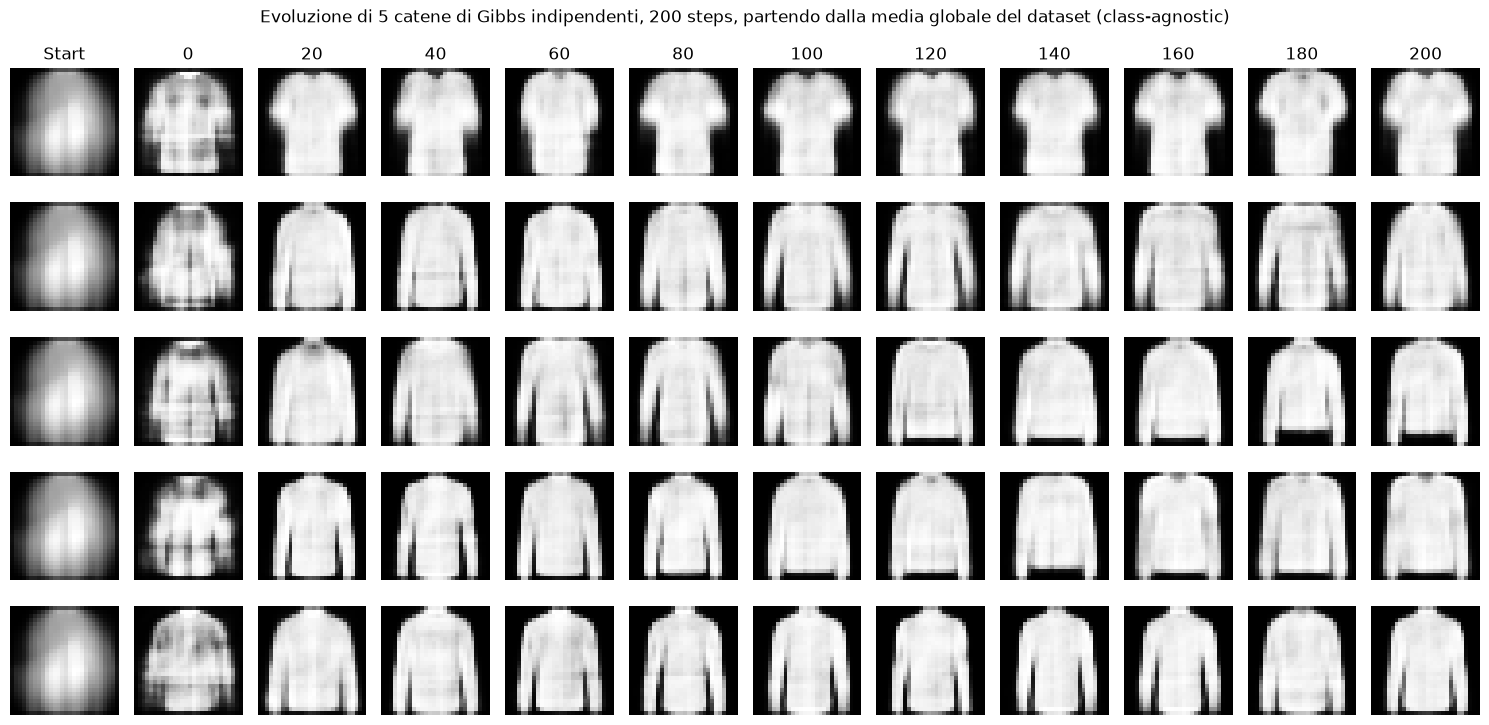

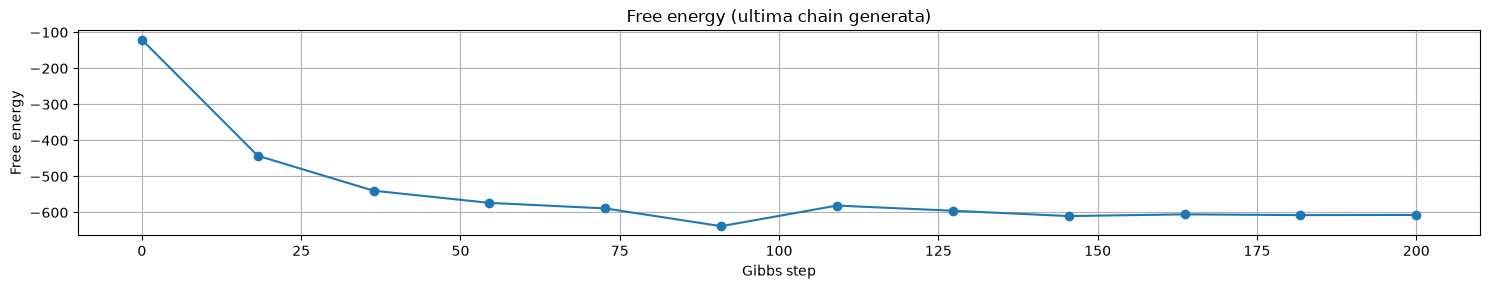

Free energy media: -542.51, std: 135.87


In [10]:
def gibbs_chain_from_data(rbm, v_init, n_steps, rng):
    v = v_init.copy()
    snapshots = [v.copy()]
    energies = [rbm.free_energy(v)]
    for t in tqdm(range(n_steps)):
        p_h = rbm.sigmoid(v @ rbm.W + rbm.c)
        h = (rng.rand(*p_h.shape) < p_h).astype(np.float64)
        p_v = rbm.sigmoid(h @ rbm.W.T + rbm.b)
        v = (rng.rand(*p_v.shape) < p_v).astype(np.float64)
        if t % (n_steps // 10) == 0:
            snapshots.append(p_v.copy())
            energies.append(rbm.free_energy(v))
    snapshots.append(p_v.copy())
    energies.append(rbm.free_energy(v))
    return snapshots, energies

# Pseudo-campione di partenza: media pixel-wise su TUTTO il dataset, indipendentemente dalla label
v_mean_global = X.mean(axis=0, keepdims=True).astype(np.float64)  # shape (1, n_visible)

rng = np.random.RandomState(47)
n_steps = K_GEN
n_chains = 5

fig, axes = plt.subplots(n_chains, 12, figsize=(15, 1.5 * n_chains))
titles = ["Start"] + [f"{int(i*n_steps/10)}" for i in range(11)]
for row in range(n_chains):
    # Stesso punto di partenza (media globale) per ogni chain: la diversità tra le righe
    # emerge unicamente dalla stocasticità del sampling (rng condiviso e avanzato tra le chain)
    v_init = v_mean_global.copy()
    snapshots, energies = gibbs_chain_from_data(rbm, v_init, n_steps=n_steps, rng=rng)
    for col, snap in enumerate(snapshots):
        ax = axes[row, col] if n_chains > 1 else axes[col]
        ax.imshow(snap.reshape(side, side), cmap='gray')
        if row == 0:
            ax.set_title(titles[col])
        ax.axis('off')

plt.suptitle(f"Evoluzione di {n_chains} catene di Gibbs indipendenti, {n_steps} steps, "
             f"partendo dalla media globale del dataset (class-agnostic)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,3))
plt.plot(np.linspace(0,n_steps,len(energies)), energies, marker='o')
plt.title("Free energy (ultima chain generata)")
plt.xlabel("Gibbs step")
plt.ylabel("Free energy")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Free energy media: {np.mean(energies):.2f}, std: {np.std(energies):.2f}')

### Inizializzazione da pseudo-campione: media condizionata sulla classe

Variante della cella precedente in cui il centroide non è calcolato sull'intero dataset, ma solo sui campioni di una classe target $c$:

$$
\bar v_c = \frac{1}{N_c}\sum_{i:\, y_i = c} v_i
$$

L'obiettivo è isolare l'effetto "distanza iniziale dal minimo del bacino" dall'effetto "ampiezza/specificità del bacino" discusso nelle conclusioni: partendo esattamente dal centroide di una classe, la catena dovrebbe convergere e stabilizzarsi rapidamente attorno a quel modo (a differenza del caso globale, qui non c'è ambiguità su quale bacino raggiungere). Confrontando la free energy e il numero di step necessari a stabilizzarsi per classi diverse, si può stimare indirettamente se alcune classi corrispondano a bacini più "profondi" (minimo più negativo) e altre a bacini più "larghi" (maggiore entropia configurazionale, come ipotizzato per "0" e per il cluster Coat/Pullover/Shirt), verificando quantitativamente l'interpretazione qualitativa proposta in precedenza.

Associazione class-ID $↔$ class name per Fashion MNIST:
| Class ID | Nome | |
|----------|-----------|------------------|
| 0 | T-shirt/top | Maglietta/top |
| 1 | Trouser | Pantalone |
| 2 | Pullover | Maglione/pullover |
| 3 | Dress | Vestito |
| 4 | Coat | Cappotto/giacca |
| 5 | Sandal | Sandalo |
| 6 | Shirt | Camicia |
| 7 | Sneaker | Scarpa da ginnastica |
| 8 | Bag | Borsa |
| 9 | Ankle boot | Stivaletto |

100%|██████████| 200/200 [00:00<00:00, 5121.69it/s]


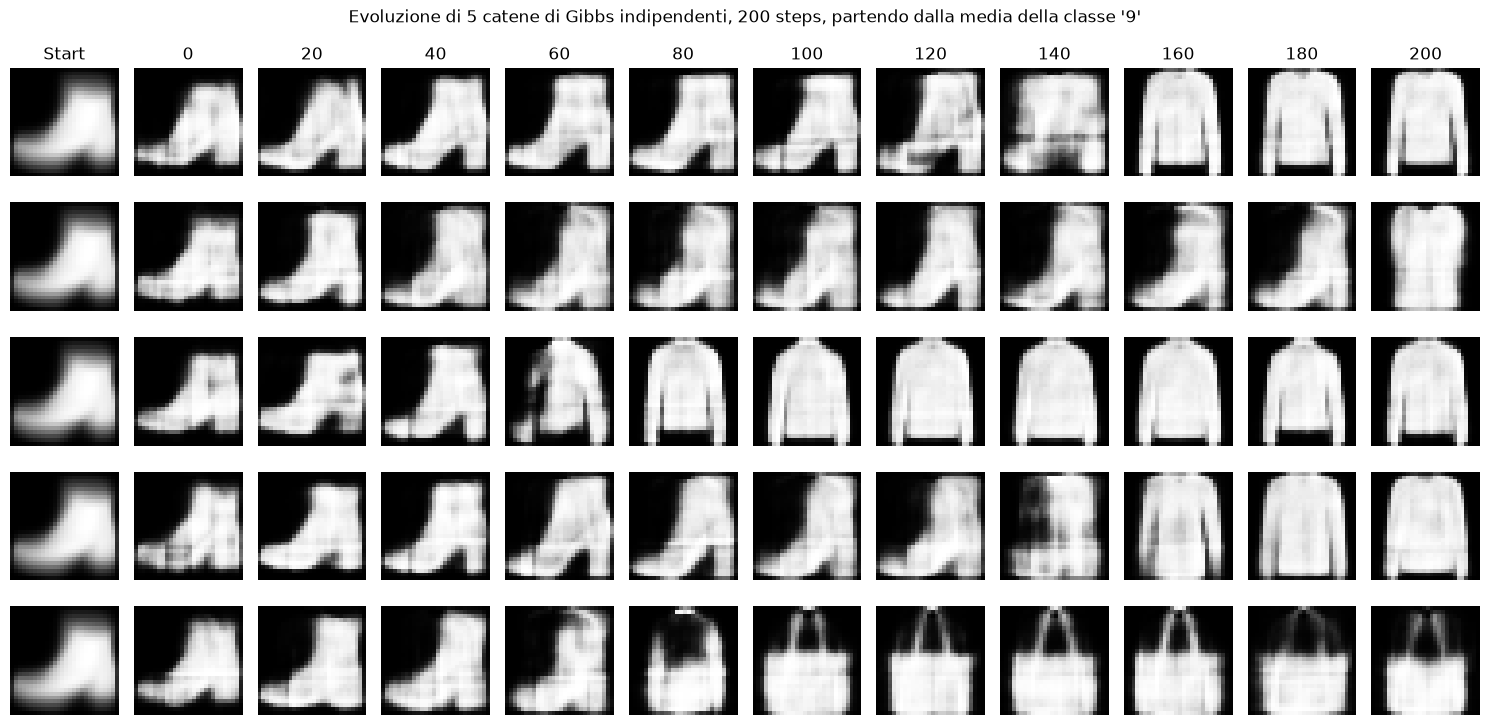

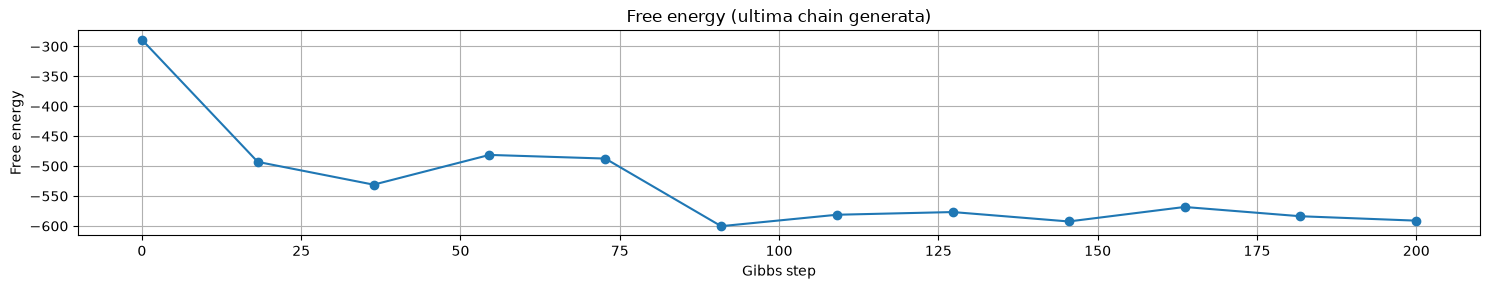

Free energy media: -531.28, std: 84.39


In [11]:
def gibbs_chain_from_data(rbm, v_init, n_steps, rng):
    v = v_init.copy()
    snapshots = [v.copy()]
    energies = [rbm.free_energy(v)]
    for t in tqdm(range(n_steps)):
        p_h = rbm.sigmoid(v @ rbm.W + rbm.c)
        h = (rng.rand(*p_h.shape) < p_h).astype(np.float64)
        p_v = rbm.sigmoid(h @ rbm.W.T + rbm.b)
        v = (rng.rand(*p_v.shape) < p_v).astype(np.float64)
        if t % (n_steps // 10) == 0:
            snapshots.append(p_v.copy())
            energies.append(rbm.free_energy(v))
    snapshots.append(p_v.copy())
    energies.append(rbm.free_energy(v))
    return snapshots, energies

# Classe target per cui calcolare il centroide
target_class = 9
y_arr = np.asarray(y).astype(int)

# Pseudo-campione di partenza: media pixel-wise SOLO delle immagini della classe target
v_mean_class = X[y_arr == target_class].mean(axis=0, keepdims=True).astype(np.float64)  # shape (1, n_visible)

rng = np.random.RandomState(47)
n_steps = K_GEN
n_chains = 5

fig, axes = plt.subplots(n_chains, 12, figsize=(15, 1.5 * n_chains))
titles = ["Start"] + [f"{int(i*n_steps/10)}" for i in range(11)]
for row in range(n_chains):
    # Stesso centroide di classe per ogni chain: la diversità tra le righe
    # emerge unicamente dalla stocasticità del sampling (rng condiviso e avanzato tra le chain)
    v_init = v_mean_class.copy()
    snapshots, energies = gibbs_chain_from_data(rbm, v_init, n_steps=n_steps, rng=rng)
    for col, snap in enumerate(snapshots):
        ax = axes[row, col] if n_chains > 1 else axes[col]
        ax.imshow(snap.reshape(side, side), cmap='gray')
        if row == 0:
            ax.set_title(titles[col])
        ax.axis('off')

plt.suptitle(f"Evoluzione di {n_chains} catene di Gibbs indipendenti, {n_steps} steps, "
             f"partendo dalla media della classe '{target_class}'")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,3))
plt.plot(np.linspace(0,n_steps,len(energies)), energies, marker='o')
plt.title("Free energy (ultima chain generata)")
plt.xlabel("Gibbs step")
plt.ylabel("Free energy")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Free energy media: {np.mean(energies):.2f}, std: {np.std(energies):.2f}')

## Conclusioni

**Espressività vs. campionabilità:** Difficoltà di campionamento non implica scarsa espressività. Su MNIST digit, i 10 modi (i.e. valli) occupano una regione minuscola dello spazio $\{0,1\}^{784}$, quindi sono "difficilmente raggiungibili".

Partendo da rumore tipo Bernoulli(0.5) la generazione non arriva mai a produrre campioni realistici e la free energy si stabilizza ad un valore relativamente alto ($\bar F \approx 100$).

Inizializzando la catena con una distribuzione più vicina alla realtà si riescono a generare campioni realistici, anche ben definiti, con $\bar F \approx -350$ a regime.

Un fattore concausale è il training **CD-k** con $k=1$, stimatore distorto (Hinton 2002; Tieleman 2008) che vincola il landscape solo vicino ai dati, lasciando le regioni lontane scarsamente scolpite. Tuttavia anche ripetendo gli esperimenti con $k$ maggiore (es. $k=5$) le conclusioni restano le stesse (forse aumenta un po' l'espressività ma non in maniera apprezzabile).

**Mode collapse:** Su MNIST digit, la chain che parte da input reale converge spesso nel bacino "0" e vi resta a lungo (pur avendo $F$ meno negativa dei modi vicini). Su Fashion-MNIST il fenomeno è più marcato: anche da rumore puro, le catene convergono su campioni realistici, ma quasi sempre della classe *Coat/Pullover/Shirt*, e catene inizializzate su altre classi tendono a migrarvi nel lungo periodo.